# DNN Strategy (EURUSD M15) — Out-of-Sample 2025

This notebook trains a DNN classifier using the reference utilities in `DNNModel.py` and evaluates a trading strategy on an **out-of-sample** test year (2025).

**Data**: `EURUSD_M15_2019-2025.csv` with columns: `time`, `price`, `spread`.

**Splits**:
- Train: 2019–2023
- Validation: 2024
- OOS Test: 2025

**Trading costs**: half-spread per position change (in return terms: $0.5×spread/price$).

Note: If you ever see `NotImplementedError: numpy() is only available when eager execution is enabled`, restart the kernel and run again from the top (some prior cell may have disabled eager execution).

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

import tensorflow as tf

# Safety: eager execution must be enabled for most Keras workflows
print('TF eager:', tf.executing_eagerly())
tf.config.run_functions_eagerly(True)  # slower, but avoids graph->numpy surprises

# Locate reference utilities (DNNModel.py) and data file
CWD = Path.cwd()
nb_dir = Path().resolve()

def find_file_upwards(filename: str) -> Path | None:
    for base in [nb_dir, CWD]:
        candidate = base / filename
        if candidate.exists():
            return candidate
    hits = list(CWD.rglob(filename))
    return hits[0] if hits else None

dnnmodel_path = find_file_upwards('DNNModel.py')
if dnnmodel_path is None:
    raise FileNotFoundError('Could not find DNNModel.py in the workspace.')

import sys
sys.path.insert(0, str(dnnmodel_path.parent))
from DNNModel import set_seeds, cw, create_model

data_path = find_file_upwards('EURUSD_M15_2019-2025.csv')
if data_path is None:
    raise FileNotFoundError('Could not find EURUSD_M15_2019-2025.csv in the workspace.')

print('Using DNNModel.py:', dnnmodel_path)
print('Using data file  :', data_path)

TF eager: True
Using DNNModel.py: C:\Users\Mohit\OneDrive\Desktop\Research Papers\ALGORITHMIC TRADING\XAI NOVELTY\DNNModel.py
Using data file  : C:\Users\Mohit\OneDrive\Desktop\Research Papers\ALGORITHMIC TRADING\XAI NOVELTY\EURUSD_M15_2019-2025.csv


In [2]:
# Load data
data = pd.read_csv(data_path, parse_dates=['time'])
data = data.sort_values('time').set_index('time')
data = data[~data.index.duplicated(keep='last')]
data[['price','spread']] = data[['price','spread']].astype(float)

# Standard return series
data['returns'] = np.log(data['price'] / data['price'].shift(1))

# Label: direction of next bar (next return) for a cleaner trading interpretation
data['fwd_ret'] = data['returns'].shift(-1)
data['dir'] = (data['fwd_ret'] > 0).astype(int)

data.dropna(inplace=True)
data[['price','spread','returns','fwd_ret','dir']].head()

,price,spread,returns,fwd_ret,dir
time,,,,,
2019-01-01 22:15:00,1.14648,0.00069,0.000140,-0.000096,0
2019-01-01 22:30:00,1.14637,0.00048,-0.000096,0.000035,1
2019-01-01 22:45:00,1.14641,0.00078,0.000035,0.000166,1
2019-01-01 23:00:00,1.14660,0.00019,0.000166,0.000044,1
2019-01-01 23:15:00,1.14665,0.00016,0.000044,-0.000131,0


In [3]:
# Feature engineering (kept close to the reference notebook style)
df = data.copy()
window = 50

# Technical features
df['sma'] = df['price'].rolling(window).mean() - df['price'].rolling(150).mean()
df['boll'] = (df['price'] - df['price'].rolling(window).mean()) / df['price'].rolling(window).std()
df['min'] = df['price'].rolling(window).min() / df['price'] - 1
df['max'] = df['price'].rolling(window).max() / df['price'] - 1
df['mom'] = df['returns'].rolling(3).mean()
df['vol'] = df['returns'].rolling(window).std()


df.dropna(inplace=True)
df.head()

,price,spread,returns,fwd_ret,dir,sma,boll,min,max,mom,vol
time,,,,,,,,,,,
2019-01-03 11:30:00,1.13498,0.00013,-0.000432,-0.000723,0,-0.003284,-0.761370,-0.003286,0.002872,-0.000552,0.000604
2019-01-03 11:45:00,1.13416,0.00015,-0.000723,0.000185,1,-0.003199,-1.342270,-0.002566,0.003597,-0.000441,0.000609
2019-01-03 12:00:00,1.13437,0.00014,0.000185,0.000397,1,-0.003101,-1.232083,-0.002750,0.003412,-0.000323,0.000605
2019-01-03 12:15:00,1.13482,0.00013,0.000397,0.000467,1,-0.002952,-1.095653,-0.000987,0.003014,-0.000047,0.000537
2019-01-03 12:30:00,1.13535,0.00012,0.000467,-0.000872,0,-0.002844,-0.715793,-0.001251,0.002545,0.000350,0.000447


In [5]:
# Add lags
lags = 5
cols = []
features = ['dir', 'sma', 'boll', 'min', 'max', 'mom', 'vol']

for f in features:
    for lag in range(1, lags + 1):
        col = f'{f}_lag_{lag}'
        df[col] = df[f].shift(lag)
        cols.append(col)

df.dropna(inplace=True)
len(cols), df.index.min(), df.index.max()

(35, Timestamp('2019-01-03 12:45:00'), Timestamp('2025-12-30 23:30:00'))

In [6]:
# Year-based split: Train 2019–2023, Validation 2024, OOS Test 2025
if not isinstance(df.index, pd.DatetimeIndex):
    df = df.copy()
    df.index = pd.to_datetime(df.index)

years = df.index.year
train = df[(years >= 2019) & (years <= 2023)].copy()
val   = df[years == 2024].copy()
test  = df[years == 2025].copy()

print('Train rows:', len(train), train.index.min(), '→', train.index.max())
print('Val rows  :', len(val),   val.index.min(),   '→', val.index.max())
print('Test rows :', len(test),  test.index.min(),  '→', test.index.max())

if len(val) == 0 or len(test) == 0:
    raise ValueError('Validation (2024) and/or Test (2025) is empty after feature engineering.')

Train rows: 124273 2019-01-03 12:45:00 → 2023-12-29 21:45:00
Val rows  : 24949 2024-01-01 22:00:00 → 2024-12-31 21:45:00
Test rows : 24775 2025-01-01 22:00:00 → 2025-12-30 23:30:00


In [7]:
# Standardization using TRAIN parameters (features only)
mu, std = train[cols].mean(), train[cols].std()
train_s = (train - mu) / std
val_s   = (val - mu) / std
test_s  = (test - mu) / std

# Numpy arrays (avoid pandas->tf conversion edge cases)
X_train, y_train = train_s[cols].to_numpy(np.float32), train['dir'].to_numpy(np.int32)
X_val,   y_val   = val_s[cols].to_numpy(np.float32),   val['dir'].to_numpy(np.int32)
X_test,  y_test  = test_s[cols].to_numpy(np.float32),  test['dir'].to_numpy(np.int32)

class_weight = cw(train[['dir']])
class_weight

{0: np.float64(0.9863719342804985), 1: np.float64(1.0140099219948433)}

In [8]:
# Train DNN (reference: create_model from DNNModel.py)
tf.keras.backend.clear_session()
set_seeds(100)

# Important: use a fresh optimizer instance per model (avoids 'Unknown variable' errors)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model = create_model(hl=3, hu=50, dropout=True, input_dim=len(cols), optimizer=optimizer)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=512,
    verbose=1,
    shuffle=False,
    class_weight=class_weight,
    callbacks=callbacks
)

pd.DataFrame(history.history)[['loss','val_loss','accuracy','val_accuracy']].tail()


Epoch 1/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.4973 - loss: 0.7058 - val_accuracy: 0.5026 - val_loss: 0.6932
Epoch 2/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.4995 - loss: 0.6983 - val_accuracy: 0.5056 - val_loss: 0.6931
Epoch 3/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.4998 - loss: 0.6963 - val_accuracy: 0.5076 - val_loss: 0.6930
Epoch 4/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.5036 - loss: 0.6950 - val_accuracy: 0.5103 - val_loss: 0.6929
Epoch 5/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - accuracy: 0.5024 - loss: 0.6948 - val_accuracy: 0.5093 - val_loss: 0.6929
Epoch 6/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - accuracy: 0.5013 - loss: 0.6943 - val_accuracy: 0.5096 - val_loss: 0.6929
Epoch 7/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - accuracy: 0.5022 - loss: 0.6942 - val_accuracy: 0.5104 - val_loss: 0.6929
Epoch 8/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.5050 - loss: 0.6938 -

,loss,val_loss,accuracy,val_accuracy
8,0.693740,0.692899,0.504116,0.507876
9,0.693430,0.692906,0.503577,0.508477
10,0.693408,0.692901,0.504840,0.507836
11,0.693291,0.692910,0.505926,0.508718
12,0.693242,0.692897,0.506981,0.510481


In [9]:
# Metrics (Validation 2024 and OOS Test 2025)
def eval_split(name, X, y):
    prob = model.predict(X, verbose=0).reshape(-1)
    pred = (prob >= 0.5).astype(int)
    acc = accuracy_score(y, pred)
    auc = roc_auc_score(y, prob) if len(np.unique(y)) > 1 else np.nan
    print(f'\n{name}: acc={acc:.4f}  auc={auc:.4f}')
    print(classification_report(y, pred, digits=4))
    return prob

val_prob = eval_split('Validation (2024)', X_val, y_val)
test_prob = eval_split('OOS Test (2025)', X_test, y_test)


Validation (2024): acc=0.5081  auc=0.5151
              precision    recall  f1-score   support

           0     0.5075    0.7545    0.6068     12552
           1     0.5099    0.2586    0.3432     12397

    accuracy                         0.5081     24949
   macro avg     0.5087    0.5066    0.4750     24949
weighted avg     0.5087    0.5081    0.4758     24949


OOS Test (2025): acc=0.5117  auc=0.5136
              precision    recall  f1-score   support

           0     0.5085    0.7455    0.6046     12406
           1     0.5206    0.2771    0.3617     12369

    accuracy                         0.5117     24775
   macro avg     0.5145    0.5113    0.4832     24775
weighted avg     0.5145    0.5117    0.4833     24775



Validation proba summary: [0.48400591 0.48832628 0.49342358 0.49671668 0.5000357  0.50626998
 0.51113894]
Test proba summary      : [0.48319394 0.48855298 0.49380374 0.49703079 0.50026649 0.50657091
 0.51176084]
Chosen strategy params from 2024 validation: {'score': 0.0703770566336334, 't': 0.53, 'ntrades': 17.0, 'mode': 'always_in'}
OOS 2025 end equity (buy&hold): 1.1345464731051915
OOS 2025 end equity (strategy net): 0.8817888684179335
Total trades (abs position changes): 12.0
OOS flat fraction (position==0): 0.0


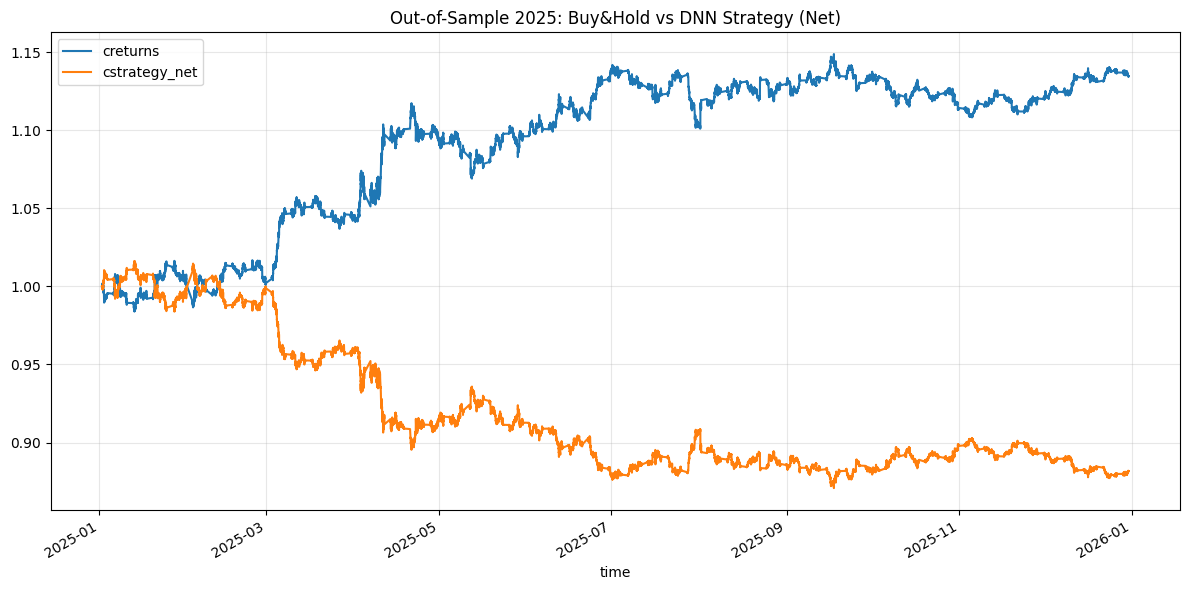

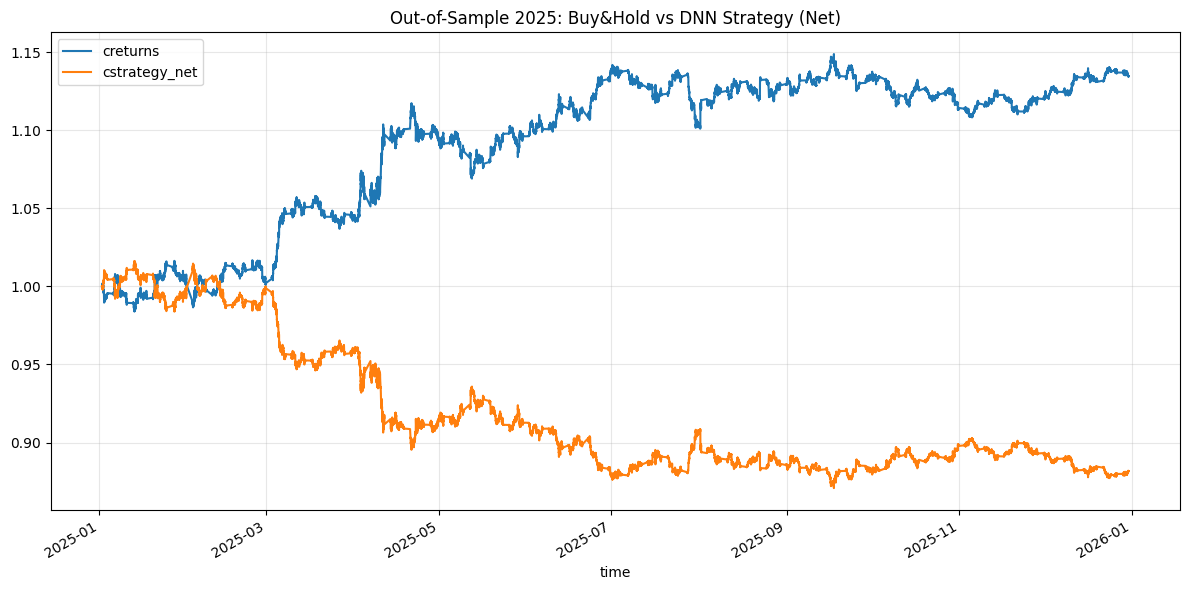

In [10]:
# Trading strategy (OOS 2025) with half-spread costs
# Two variants:
#   1) Band strategy: short if prob < lower, long if prob > upper, else flat
#   2) Always-in strategy: long if prob > t else short
# We tune thresholds ONLY on 2024 validation to avoid peeking into 2025.

import numpy as np


def positions_band(prob, lower=0.47, upper=0.53):
    pos = np.zeros_like(prob, dtype=float)
    pos[prob < lower] = -1.0
    pos[prob > upper] = 1.0
    return pos


def positions_always_in(prob, t=0.5):
    return np.where(prob > t, 1.0, -1.0).astype(float)


def score_positions(pos, returns, spread, price):
    # trade on next bar: shift position by 1
    strat = np.r_[0.0, pos[:-1]] * returns
    trades = np.abs(np.diff(np.r_[0.0, pos]))
    ptc = 0.5 * (spread / price)  # half-spread cost
    net = strat - trades * ptc
    return net.sum(), trades.sum()


# Diagnostics: if probs are too concentrated, the band strategy stays flat.
print('Validation proba summary:', np.quantile(val_prob, [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
print('Test proba summary      :', np.quantile(test_prob, [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

val_returns = val['returns'].to_numpy()
val_spread = val['spread'].to_numpy()
val_price = val['price'].to_numpy()

# Enforce activity so tuning doesn't "win" by staying out of the market.
# Adjust these if you want more/less activity.
MIN_TRADES_VAL = 50.0
MAX_FLAT_FRAC_VAL = 0.80  # at most 80% of time in cash for band strategy

best_band = None
for lower in np.round(np.arange(0.40, 0.51, 0.01), 2):
    for upper in np.round(np.arange(0.49, 0.61, 0.01), 2):
        if lower > upper:
            continue
        pos = positions_band(val_prob, lower, upper)
        flat_frac = float((pos == 0.0).mean())
        score, ntrades = score_positions(pos, val_returns, val_spread, val_price)
        if (ntrades < MIN_TRADES_VAL) or (flat_frac > MAX_FLAT_FRAC_VAL):
            continue
        if (best_band is None) or (score > best_band['score']):
            best_band = {
                'score': float(score),
                'lower': float(lower),
                'upper': float(upper),
                'ntrades': float(ntrades),
                'flat_frac': float(flat_frac),
                'mode': 'band',
            }

best_always = None
for t in np.round(np.arange(0.45, 0.56, 0.01), 2):
    pos = positions_always_in(val_prob, t)
    score, ntrades = score_positions(pos, val_returns, val_spread, val_price)
    if (best_always is None) or (score > best_always['score']):
        best_always = {
            'score': float(score),
            't': float(t),
            'ntrades': float(ntrades),
            'mode': 'always_in',
        }

# Pick best available; if band can't satisfy activity constraints, always-in is used.
if best_band is None:
    chosen = best_always
else:
    chosen = best_band if best_band['score'] >= best_always['score'] else best_always

print('Chosen strategy params from 2024 validation:', chosen)

# Build OOS 2025 backtest
test_bt = test.copy()
test_bt['proba'] = test_prob

if chosen['mode'] == 'band':
    test_bt['position'] = positions_band(test_bt['proba'].to_numpy(), chosen['lower'], chosen['upper'])
else:
    test_bt['position'] = positions_always_in(test_bt['proba'].to_numpy(), chosen['t'])

# Trade on next bar to avoid lookahead
test_bt['strategy'] = test_bt['position'].shift(1).fillna(0.0) * test_bt['returns']

# Costs: half-spread per 1-unit position change
test_bt['trades'] = test_bt['position'].diff().abs().fillna(0.0)
test_bt['ptc'] = 0.5 * (test_bt['spread'] / test_bt['price'])
test_bt['strategy_net'] = test_bt['strategy'] - test_bt['trades'] * test_bt['ptc']

test_bt['creturns'] = test_bt['returns'].cumsum().apply(np.exp)
test_bt['cstrategy_net'] = test_bt['strategy_net'].cumsum().apply(np.exp)

print('OOS 2025 end equity (buy&hold):', float(test_bt['creturns'].iloc[-1]))
print('OOS 2025 end equity (strategy net):', float(test_bt['cstrategy_net'].iloc[-1]))
print('Total trades (abs position changes):', float(test_bt['trades'].sum()))
print('OOS flat fraction (position==0):', float((test_bt['position'] == 0.0).mean()))

ax = test_bt[['creturns', 'cstrategy_net']].plot(
    figsize=(12, 6),
    title='Out-of-Sample 2025: Buy&Hold vs DNN Strategy (Net)'
)
ax.grid(True, alpha=0.3) 
ax.figure.tight_layout()
ax.figure

In [11]:
# Quick fix: ALWAYS-IN strategy (never flat) on OOS 2025
# long if proba > 0.5 else short

test_bt_ai = test.copy()
test_bt_ai['proba'] = test_prob

test_bt_ai['position'] = np.where(test_bt_ai['proba'].to_numpy() > 0.5, 1.0, -1.0)

test_bt_ai['strategy'] = test_bt_ai['position'].shift(1).fillna(0.0) * test_bt_ai['returns']
test_bt_ai['trades'] = test_bt_ai['position'].diff().abs().fillna(0.0)
test_bt_ai['ptc'] = 0.5 * (test_bt_ai['spread'] / test_bt_ai['price'])
test_bt_ai['strategy_net'] = test_bt_ai['strategy'] - test_bt_ai['trades'] * test_bt_ai['ptc']

test_bt_ai['cstrategy_net'] = test_bt_ai['strategy_net'].cumsum().apply(np.exp)

print('ALWAYS-IN OOS 2025 end equity (strategy net):', float(test_bt_ai['cstrategy_net'].iloc[-1]))
print('ALWAYS-IN total trades:', float(test_bt_ai['trades'].sum()))
print('ALWAYS-IN flat fraction (position==0):', float((test_bt_ai['position'] == 0.0).mean()))
print('ALWAYS-IN strategy_net std:', float(test_bt_ai['strategy_net'].std()))

ALWAYS-IN OOS 2025 end equity (strategy net): 0.4131796056939719
ALWAYS-IN total trades: 13030.0
ALWAYS-IN flat fraction (position==0): 0.0
ALWAYS-IN strategy_net std: 0.0005219231396179621
